In [1]:
import pandas as pd

In [2]:
plots = pd.read_parquet('/Users/sala6791/Library/CloudStorage/OneDrive-UCB-O365/Documents/EAGLE/datasets/NPS_VMI/vmi_core_events.parquet')

In [7]:
plots['community_name'].value_counts().head(20)

community_name
TSUMER/PHYEMP-VACDEL                                                             166
Low Elevation Creosotebush Desert Scrub                                          152
TSUMER-ABIAMA/RHOALB                                                             123
PSEMEN-TSUHET/MAHNER                                                             117
PHYEMP-VACDEL-(CASMER)                                                           115
CASMER-PHYEMP                                                                    109
TSUHET-PSEMEN/MAHNER-CHIMEN                                                      107
Sporobolus nealleyi / Tiquilia hispidissima Dwarf-shrub Herbaceous Vegetation    104
TSUMER-ABILAS/VACDEL-PHYEMP                                                       98
ABIAMA-(TSUHET)/VACMEM                                                            95
Sporobolus airoides Monotypic Grassland                                           94
ABILAS/VACDEL                                     

In [5]:
plots['nvc_code'].value_counts().head(20)

nvc_code
Unassigned    158
CEGL001546    104
CEGL000862    102
CEGL007489     99
CEGL002070     95
NHNM000891     85
A.783          79
NPS_NM049      76
CEGL002151     74
NPS_NM077      74
NHNM000255     73
CEGL001291     70
CEGL006599     66
CEGL005379     66
CEGL005033     66
NPS_NM088      66
CEGL002381     65
CEGL000710     65
NPSCAVE04      64
CEGL001382     64
Name: count, dtype: int64[pyarrow]

In [11]:
plots.columns

Index(['event_key', 'package', 'unit_code', 'schema_family', 'plot_type',
       'plot_code', 'event_date', 'x_raw', 'y_raw', 'utm_zone_raw',
       'datum_raw', 'lon', 'lat', 'bbox_dist_deg', 'nvc_code',
       'community_name', 'elevation_m', 'plot_area_note', 'qa_flags',
       'event_id', 'year'],
      dtype='str')

In [16]:
import geopandas as gpd
import contextily as ctx
import colorcet
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = mpl.colors.ListedColormap(colorcet.glasbey)


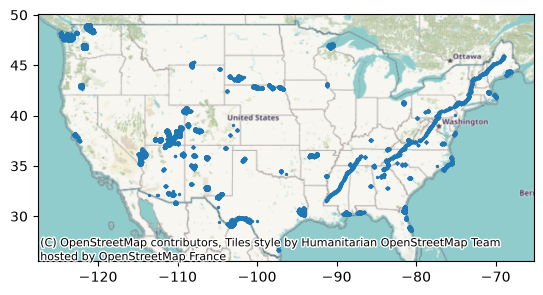

In [24]:
gdf = gpd.GeoDataFrame(plots, geometry=gpd.points_from_xy(plots['lon'], plots['lat']), crs='EPSG:4326')
gdf = gdf.cx[-125:-66, 25:50] # limit to conus
ax=gdf.plot(markersize=2)
ctx.add_basemap(ax, crs=gdf.crs.to_string())
